# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 66.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not c

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [19]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input
from tensorflow.keras import optimizers
from tensorflow.keras import losses                                       # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


In [ ]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [32]:
from google.colab import drive
drive.mount('/content/drive')



# Load the labels file of the dataset
labels = pd.read_csv('labels.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
images = np.load('/content/drive/MyDrive/ColabNotebooks/images.npy')



# **Exploratory Data Analysis**

Let's Print the Images and shape

In [ ]:
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)




*   There are 4125 images in the dataset.
*   Each image is shape of 200 * 200, with 3 channels.



###Plot random images from each of the classes and print their corresponding labels.

In [39]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

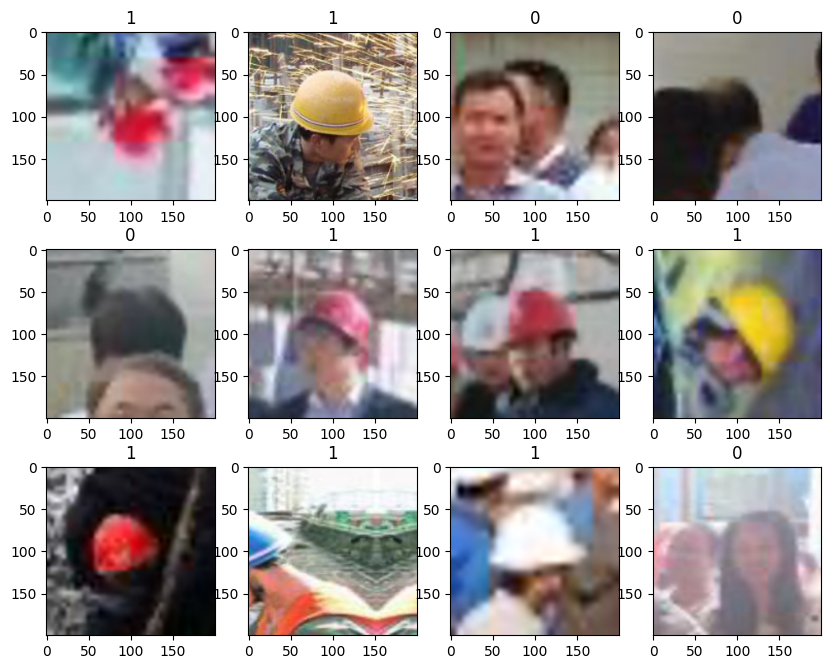

In [40]:
plot_images(images,labels)



*   Some images are blury.
*   Some are clubbed together.
*  Few are reverted.
*  Few images has multiple workers.



Visualizing images using Gaussian Blur

In [41]:
# Applying Gaussian Blur to denoise the images
images_gb=[]
for i in range(len(images)):
    images_gb.append(cv2.GaussianBlur(images[i], ksize =(3,3),sigmaX =  0))

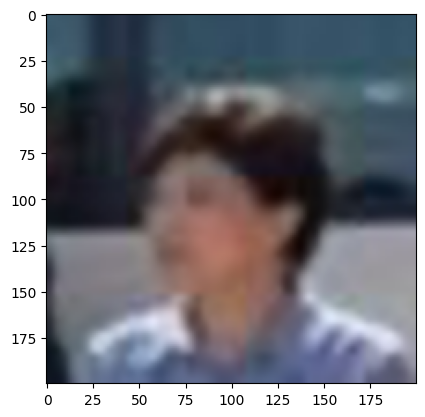

In [42]:
plt.imshow(images_gb[3]);

Grayscale Images

In [43]:
gray_images = []
for i in range(len(images)):
  gray_images.append(cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY))

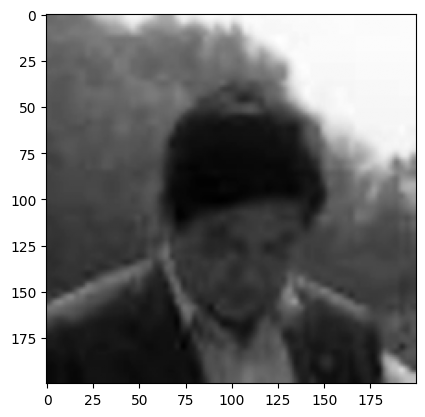

In [44]:
plt.imshow(gray_images[4], cmap='gray')

Laplacian Filter

In [45]:
# Function to plot the original and processed images side by side
def grid_plot(img1,img2,gray=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img1)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    if gray:
      axes[1].imshow(img2,cmap='gray')
    else:
      axes[1].imshow(img2)
    axes[1].set_title('Processed Image')
    axes[1].axis('off')

    plt.show()

In [46]:
edge_images = []
for i in range(len(gray_images)):
    edge_images.append(cv2.Laplacian(gray_images[i],cv2.CV_64F))

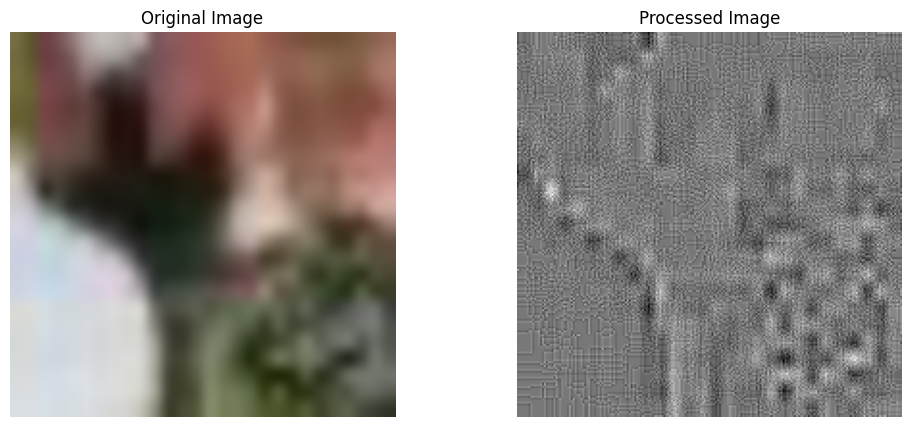

In [47]:
# choosing an image
n = 5
# plotting the original and preprocessed image
grid_plot(images[n],edge_images[n],gray=True)

In [48]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

## Checking for class imbalance


In [49]:
labels['label'].value_counts()

,count
label,
1,3161
0,964




*   There are 3161 images in which workers are wearing the Helmets and in 964 images, the workers are not wearing helmets.
*   The data is highly imbalance.
*  There are multiple ways to solve this imbalance by using the class weights, oversampling/undersampling, Data Agumentation.
*  Will use the Data Agumentaion in one of the model to see it improves the prediction rate.



# **Data Preprocessing**

### Splitting the dataset



In [50]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [51]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3300, 200, 200, 3) (3300, 1)
(412, 200, 200, 3) (412, 1)
(413, 200, 200, 3) (413, 1)


Encoding the target labels

In [52]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

### Data Normalization

In [53]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

##Model Evaluation Criterion

In this use case (helmet detection for safety compliance), a false negative—failing to detect a worker not wearing a helmet—is much more dangerous than a false positive.

*  **False negative**  → system misses a violation → worker remains at risk → possible injury or fatality
*  **False positive**  → system flags a compliant worker → minor inconvenience (e.g., unnecessary alert)

**Because the cost of missing a violation is much higher**, we want a model that catches as many true violations as possible → that’s **high recall**.

## Utility Functions

In [54]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [55]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [56]:
train_datagen = ImageDataGenerator()

In [57]:
num_classes = labels['label'].nunique()
image_size = X_train_normalized[0].size
shape = X_train_normalized.shape[1:]

In [58]:
model_1 = Sequential()
model_1.add(Input(shape=(200, 200, 3)))
model_1.add(Conv2D(32, (3,3), activation='relu',padding="same"))
model_1.add(MaxPooling2D(2,2))

model_1.add(Conv2D(64, (3,3), activation='relu',padding="same"))
model_1.add(MaxPooling2D(2,2))
model_1.add(Flatten())
model_1.add(Dense(64, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

*  Since we selected matric as recall and right now, recall metric is focused on the wrong class i.e. 1 . we can explicitly track recall for class 0.
*  The output is single sigmoid nuron, then we should be using binary classification loss i.e. binary_crossentropy.

In [59]:
adam = optimizers.Adam()
model_1.compile(loss=losses.binary_crossentropy, optimizer=adam, metrics = [tf.keras.metrics.Recall(class_id=0, name='recall_no_helmet')])

In [60]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    10,240,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,259,521 (39.14 MB)

 Trainable params: 10,259,521 (39.14 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history_1 = model_1.fit(train_datagen.flow(X_train_normalized,y_train_encoded,batch_size=128),validation_data = (X_val_normalized,y_val_encoded),epochs=15, verbose=2)

Epoch 1/15
26/26 - 25s - 971ms/step - loss: 1.3341 - recall_no_helmet: 0.7181 - val_loss: 0.5219 - val_recall_no_helmet: 1.0000
Epoch 2/15
26/26 - 4s - 147ms/step - loss: 0.4583 - recall_no_helmet: 1.0000 - val_loss: 0.3889 - val_recall_no_helmet: 1.0000
Epoch 3/15
26/26 - 5s - 205ms/step - loss: 0.3334 - recall_no_helmet: 1.0000 - val_loss: 0.2743 - val_recall_no_helmet: 1.0000
Epoch 4/15
26/26 - 4s - 141ms/step - loss: 0.2780 - recall_no_helmet: 0.9992 - val_loss: 0.2543 - val_recall_no_helmet: 0.9905
Epoch 5/15
26/26 - 4s - 139ms/step - loss: 0.2636 - recall_no_helmet: 0.9873 - val_loss: 0.2519 - val_recall_no_helmet: 0.9905
Epoch 6/15
26/26 - 4s - 159ms/step - loss: 0.2523 - recall_no_helmet: 0.9850 - val_loss: 0.2439 - val_recall_no_helmet: 0.9778
Epoch 7/15
26/26 - 4s - 148ms/step - loss: 0.2455 - recall_no_helmet: 0.9846 - val_loss: 0.2432 - val_recall_no_helmet: 0.9810
Epoch 8/15
26/26 - 4s - 141ms/step - loss: 0.2350 - recall_no_helmet: 0.9873 - val_loss: 0.2336 - val_recall_n

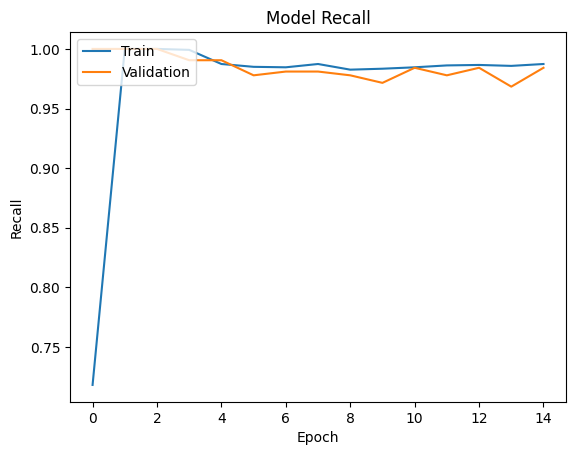

In [62]:
plt.plot(history_1.history['recall_no_helmet'])
plt.plot(history_1.history['val_recall_no_helmet'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [63]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_1_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.955758  0.916137   0.958949  0.935288


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


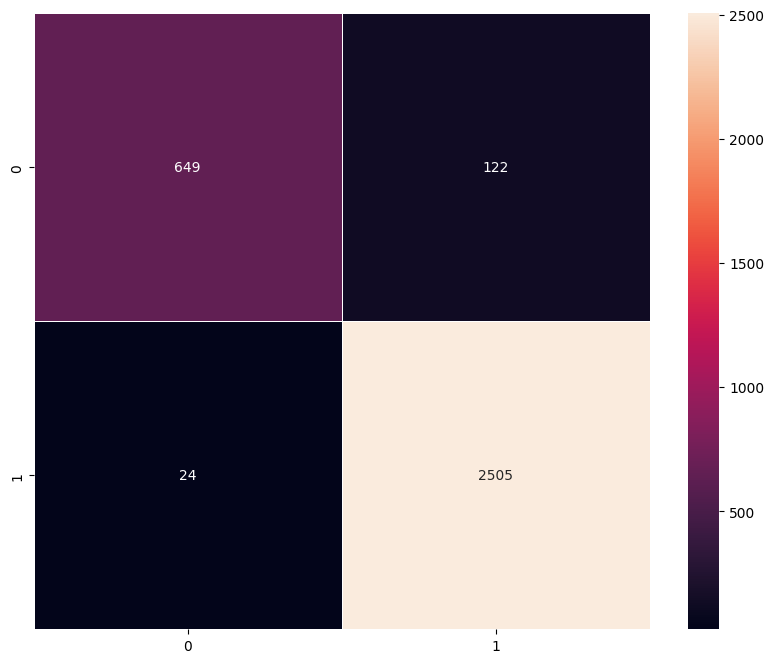

In [64]:
plot_confusion_matrix(model_1,X_train_normalized,y_train_encoded)

In [65]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_1_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.924757  0.856672   0.928091   0.88562


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


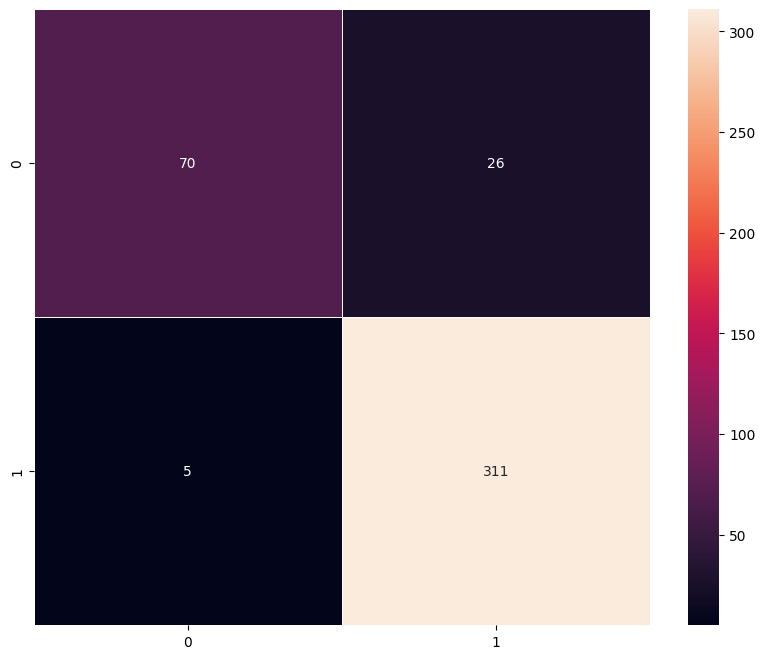

In [66]:
plot_confusion_matrix(model_1,X_val_normalized,y_val_encoded)

**Observations:**

* The model achieves approximately 91% recall on the training dataset.
* However, recall drops to around 85% on the validation dataset, indicating potential overfitting.


Lets Try adding dropout to see if the overfitting can be reduced.



*   We will incorporate a dropout layer with a dropout rate of 40%, meaning that during training, 40% of the neurons will be randomly deactivated to reduce overfitting and improve generalization




In [67]:
model_2 = Sequential()
model_2.add(Input(shape=(200, 200, 3)))
model_2.add(Conv2D(128, (3,3), activation='relu',padding="same"))
model_2.add(MaxPooling2D(2,2))

model_2.add(Dropout(0.4))

model_2.add(Conv2D(64, (3,3), activation='relu',padding="same"))
model_2.add(MaxPooling2D(2,2))


model_2.add(Flatten())
model_2.add(Dense(64, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

In [68]:
adam = optimizers.Adam()
model_2.compile(loss=losses.binary_crossentropy, optimizer=adam, metrics = [tf.keras.metrics.Recall(class_id=0, name='recall_no_helmet')])

In [69]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 200, 200, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 100, 100, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    10,240,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,317,505 (39.36 MB)

 Trainable params: 10,317,505 (39.36 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train_encoded,batch_size=128),validation_data = (X_val_normalized,y_val_encoded),epochs=15, verbose=2)

Epoch 1/15
26/26 - 53s - 2s/step - loss: 1.2675 - recall_no_helmet: 0.9122 - val_loss: 0.5861 - val_recall_no_helmet: 1.0000
Epoch 2/15
26/26 - 12s - 453ms/step - loss: 0.3551 - recall_no_helmet: 0.9775 - val_loss: 0.2896 - val_recall_no_helmet: 0.8671
Epoch 3/15
26/26 - 12s - 443ms/step - loss: 0.2608 - recall_no_helmet: 0.9502 - val_loss: 0.2389 - val_recall_no_helmet: 0.9494
Epoch 4/15
26/26 - 11s - 420ms/step - loss: 0.2306 - recall_no_helmet: 0.9478 - val_loss: 0.2831 - val_recall_no_helmet: 0.9019
Epoch 5/15
26/26 - 11s - 412ms/step - loss: 0.2075 - recall_no_helmet: 0.9609 - val_loss: 0.1971 - val_recall_no_helmet: 0.9494
Epoch 6/15
26/26 - 11s - 413ms/step - loss: 0.2065 - recall_no_helmet: 0.9529 - val_loss: 0.2401 - val_recall_no_helmet: 0.9335
Epoch 7/15
26/26 - 11s - 421ms/step - loss: 0.1946 - recall_no_helmet: 0.9609 - val_loss: 0.2832 - val_recall_no_helmet: 0.8703
Epoch 8/15
26/26 - 11s - 425ms/step - loss: 0.1785 - recall_no_helmet: 0.9620 - val_loss: 0.2100 - val_reca

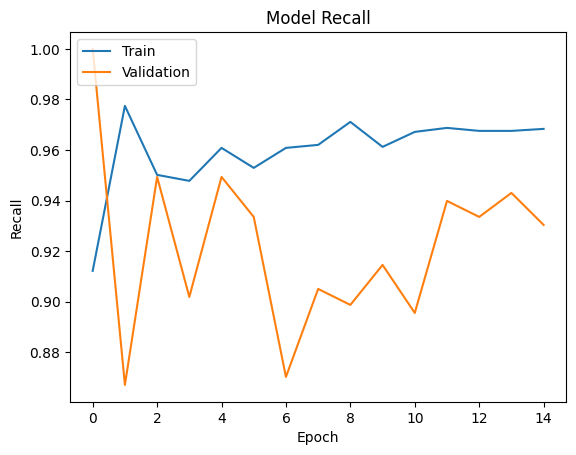

In [71]:
plt.plot(history_2.history['recall_no_helmet'])
plt.plot(history_2.history['val_recall_no_helmet'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [72]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_2_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.951818  0.938812    0.92854  0.933529


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


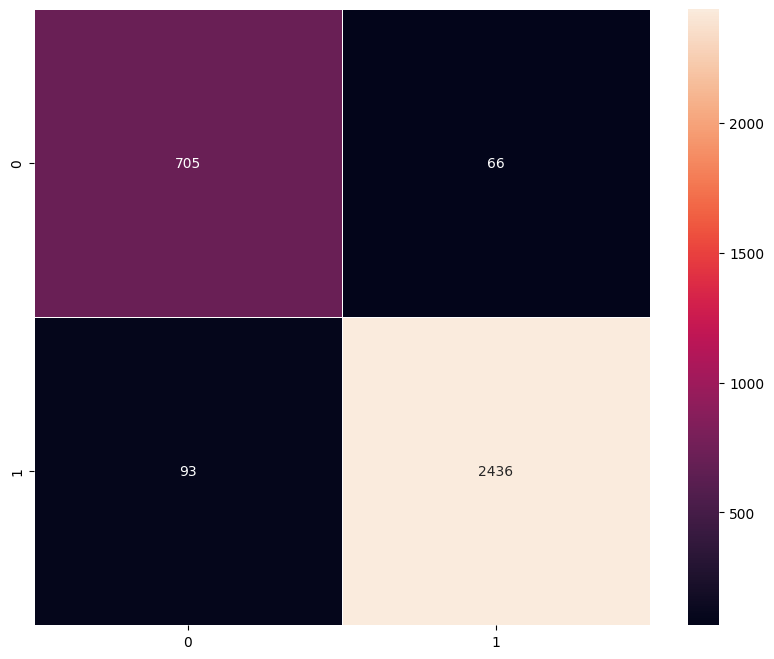

In [73]:
plot_confusion_matrix(model_2,X_train_normalized,y_train_encoded)

In [74]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_2_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.900485  0.866232   0.858537   0.86228


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


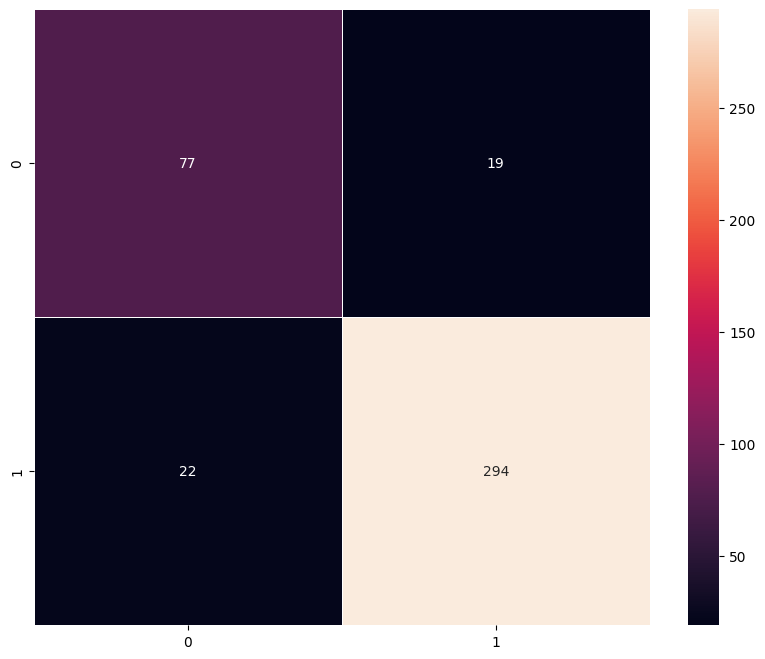

In [75]:
plot_confusion_matrix(model_2,X_val_normalized,y_val_encoded)



* The difference between training recall and validation reduced.  
* But adding the dropout the model is still overfitting.



### Visualizing the predictions

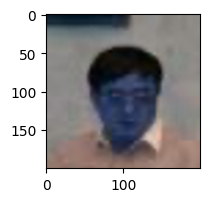

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
Predicted Label [0]
True Label 0


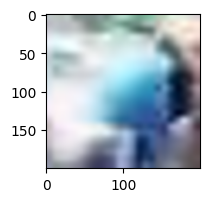

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label [1]
True Label 1


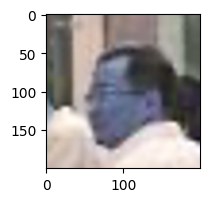

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Label [0]
True Label 0


In [76]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_2.predict((X_val_normalized[2].reshape(1,200,200,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
print('Predicted Label', enc.inverse_transform(model_2.predict((X_val_normalized[33].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()
print('Predicted Label', enc.inverse_transform(model_2.predict((X_val_normalized[36].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val)[36])

## Model 2: Transfer Learning with VGG-16 (Base)

* We will be loading a pre-built architecture - VGG16, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

* For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer (output).

In [77]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [79]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [80]:
adam = optimizers.Adam()
model_3.compile(loss=losses.binary_crossentropy, optimizer=adam, metrics = [tf.keras.metrics.Recall(class_id=0, name='recall_no_helmet')])

In [81]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [82]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_vgg16_3 = model_3.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val_encoded),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - loss: 0.4690 - recall_no_helmet: 0.9365 - val_loss: 0.3367 - val_recall_no_helmet: 0.9905
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.3073 - recall_no_helmet: 1.0000 - val_loss: 0.3321 - val_recall_no_helmet: 0.9873
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 723ms/step - loss: 0.2846 - recall_no_helmet: 0.9770 - val_loss: 0.2896 - val_recall_no_helmet: 0.9937
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.2619 - recall_no_helmet: 0.9898 - val_loss: 0.2884 - val_recall_no_helmet: 0.9937
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 810ms/step - loss: 0.2392 - recall_no_helmet: 0.9761 - val_loss: 0.2459 - val_recall_no_helmet: 0.9873
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.2249 - recall_no_helmet: 0.9901 - val_loss: 0.2495 - val_recall_no_helmet: 0.9937
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 852ms/step - loss: 0.2112 - recall_no_helmet: 0.9782 - val_loss: 0.2463 - val_recall_no_helme

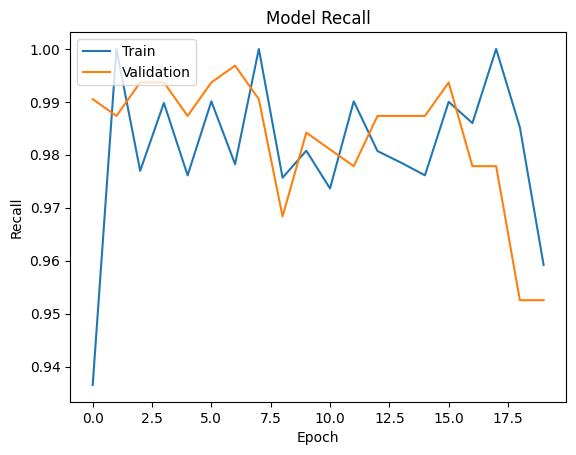

In [83]:
plt.plot(history_vgg16_3.history['recall_no_helmet'])
plt.plot(history_vgg16_3.history['val_recall_no_helmet'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [84]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_3_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.962424  0.949338   0.946135  0.947723


104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step


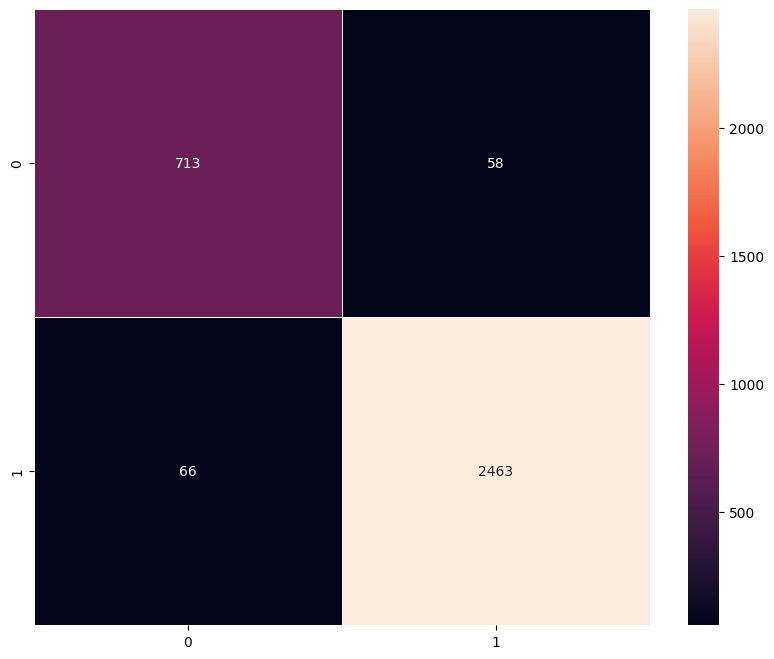

In [85]:
plot_confusion_matrix(model_3,X_train_normalized,y_train_encoded)

In [86]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_3_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0   0.92233  0.887724   0.893483  0.890553


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step


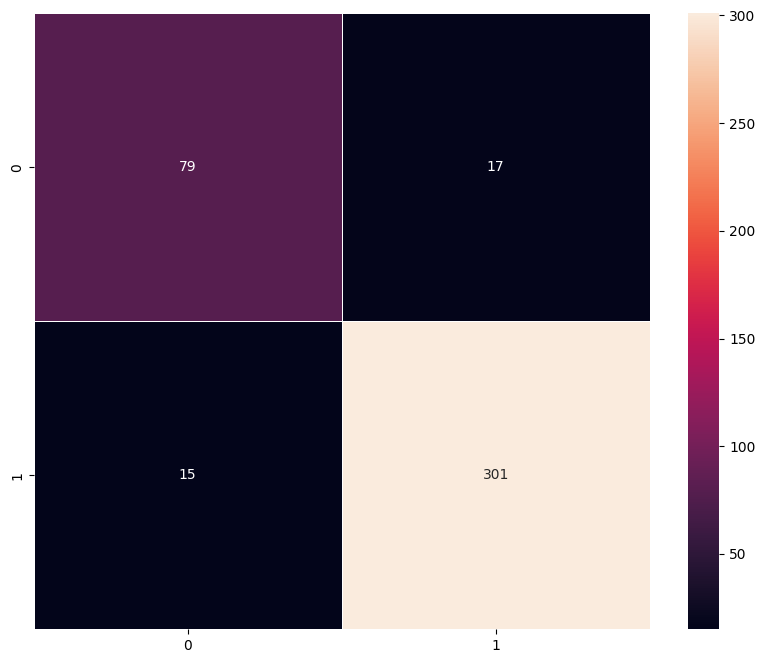

In [87]:
plot_confusion_matrix(model_3,X_val_normalized,y_val_encoded)


**Observations:**

* The model achieves approximately around 95% recall score on the training dataset.
* However, recall drops to around around 89% on the validation dataset.
* The model is well generalized.



### Visualizing the predictions

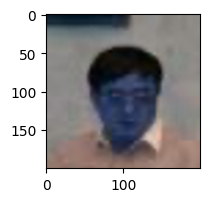

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Label [0]
True Label 0


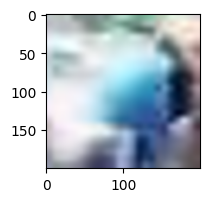

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Label [1]
True Label 1


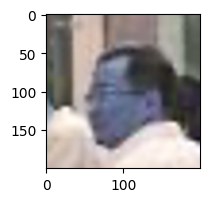

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Label [0]
True Label 0


In [88]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_3.predict((X_val_normalized[2].reshape(1,200,200,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
print('Predicted Label', enc.inverse_transform(model_3.predict((X_val_normalized[33].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()
print('Predicted Label', enc.inverse_transform(model_3.predict((X_val_normalized[36].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[36])

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





* We will directly use the convolutional and pooling layers (VGG-16) and freeze their weights i.e. no training will be done on them.
* For binary classification, we will add a Flatten layer and a Feed Forward Neural Network.

In [89]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(128,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [90]:
adam = optimizers.Adam()
model_4.compile(loss=losses.binary_crossentropy, optimizer=adam, metrics = [tf.keras.metrics.Recall(class_id=0, name='recall_no_helmet')])

In [91]:
# Generating the summary of the model
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466,561 (74.26 MB)

 Trainable params: 4,751,873 (18.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [92]:

history_vgg16_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val_encoded),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 975ms/step - loss: 0.7080 - recall_no_helmet: 0.8673 - val_loss: 0.3803 - val_recall_no_helmet: 0.9968
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.4360 - recall_no_helmet: 0.9789 - val_loss: 0.3734 - val_recall_no_helmet: 1.0000
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 832ms/step - loss: 0.3407 - recall_no_helmet: 0.9584 - val_loss: 0.2752 - val_recall_no_helmet: 0.9778
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.2716 - recall_no_helmet: 0.9293 - val_loss: 0.2810 - val_recall_no_helmet: 0.9873
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 722ms/step - loss: 0.2548 - recall_no_helmet: 0.9538 - val_loss: 0.2305 - val_recall_no_helmet: 0.9842
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.3074 - recall_no_helmet: 0.9880 - val_loss: 0.2211 - val_recall_no_helmet: 0.9684
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 753ms/step - loss: 0.2124 - recall_no_helmet: 0.9551 - val_loss: 0.1987 - val_recall_no_hel

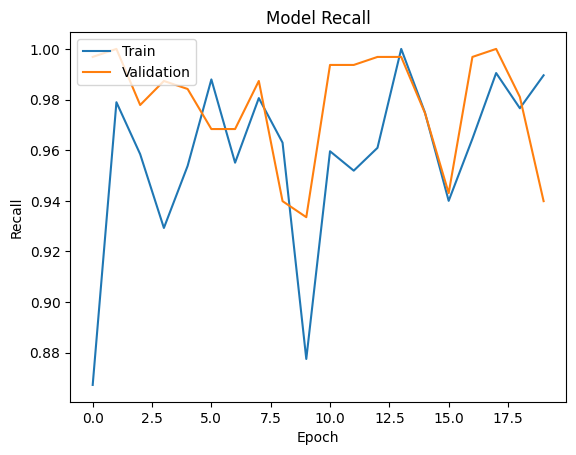

In [93]:
plt.plot(history_vgg16_4.history['recall_no_helmet'])
plt.plot(history_vgg16_4.history['val_recall_no_helmet'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [94]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_4_train_perf)


104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 208ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.968485  0.967267    0.94766  0.956953


104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step


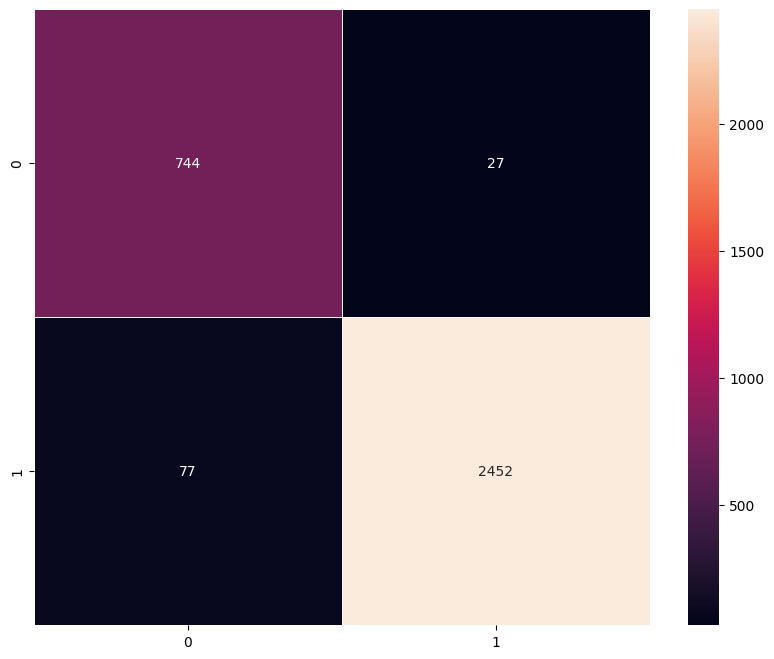

In [95]:
plot_confusion_matrix(model_4,X_train_normalized,y_train_encoded)

In [96]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_4_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.917476  0.891812   0.880962  0.886195


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step


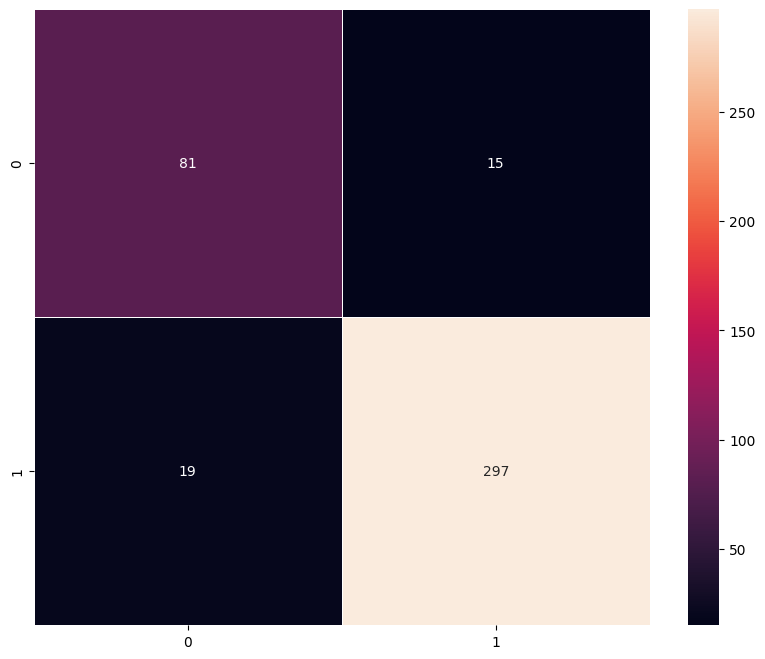

In [97]:
plot_confusion_matrix(model_4,X_val_normalized,y_val_encoded)

**Observations:**

* The model achieves approximately around 97% recall score on the training dataset.
* However, recall drops to around around 89% on the validation dataset.
* The model is overfitting as the difference in training and validation is more.

#### Visualizing the predictions

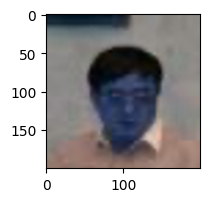

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
Predicted Label [0]
True Label 0


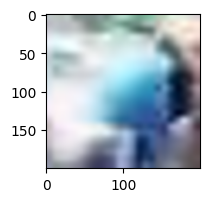

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Label [1]
True Label 1


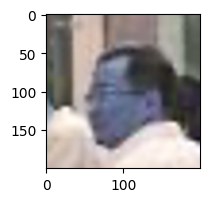

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Label [0]
True Label 0


In [98]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_4.predict((X_val_normalized[2].reshape(1,200,200,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
print('Predicted Label', enc.inverse_transform(model_4.predict((X_val_normalized[33].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()
print('Predicted Label', enc.inverse_transform(model_4.predict((X_val_normalized[36].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[36])

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [99]:
model_5 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_5.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_5.add(Flatten())

#Adding the Feed Forward neural network
model_5.add(Dense(256,activation='relu'))
model_5.add(Dropout(rate=0.4))
model_5.add(Dense(128,activation='relu'))
model_5.add(Dense(64,activation='relu'))
# Adding a dense output layer
model_5.add(Dense(1, activation='sigmoid'))

In [100]:
adam = optimizers.Adam()
model_5.compile(loss=losses.binary_crossentropy, optimizer=adam, metrics = [tf.keras.metrics.Recall(class_id=0, name='recall_no_helmet')])

In [101]:
# Generating the summary of the model
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,474,753 (74.29 MB)

 Trainable params: 4,760,065 (18.16 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [102]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',
                              width_shift_range=0.2,
                              height_shift_range=0.2,
                              shear_range=0.3,
                              zoom_range=0.4
                              )

In [103]:
history_vgg16_5 = model_5.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val_encoded),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - loss: 0.5862 - recall_no_helmet: 0.9178 - val_loss: 0.4505 - val_recall_no_helmet: 1.0000
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.5164 - recall_no_helmet: 0.9726 - val_loss: 0.4614 - val_recall_no_helmet: 1.0000
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - loss: 0.4818 - recall_no_helmet: 0.9535 - val_loss: 0.4217 - val_recall_no_helmet: 0.8449
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.4344 - recall_no_helmet: 0.9082 - val_loss: 0.4084 - val_recall_no_helmet: 0.8544
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - loss: 0.4101 - recall_no_helmet: 0.9425 - val_loss: 0.3733 - val_recall_no_helmet: 0.8259
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.4251 - recall_no_helmet: 0.8333 - val_loss: 0.3423 - val_recall_no_helmet: 0.8861
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - loss: 0.3800 - recall_no_helmet: 0.9408 - val_loss: 0.2999 - val_recall_no_helmet: 0.9873


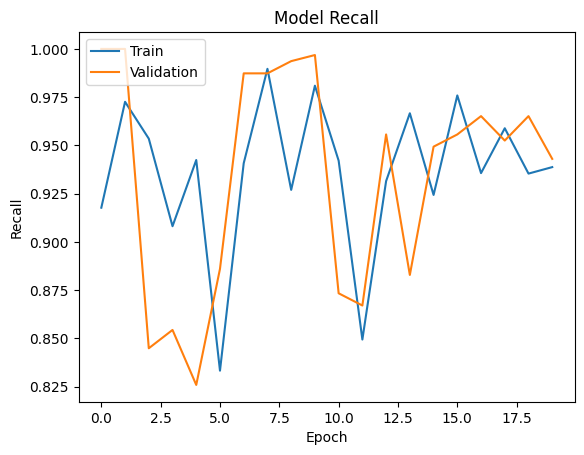

In [104]:
plt.plot(history_vgg16_5.history['recall_no_helmet'])
plt.plot(history_vgg16_5.history['val_recall_no_helmet'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [105]:
model_5_train_perf = model_performance_classification(model_5, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_5_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.909394  0.879126   0.870885  0.874891


104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step


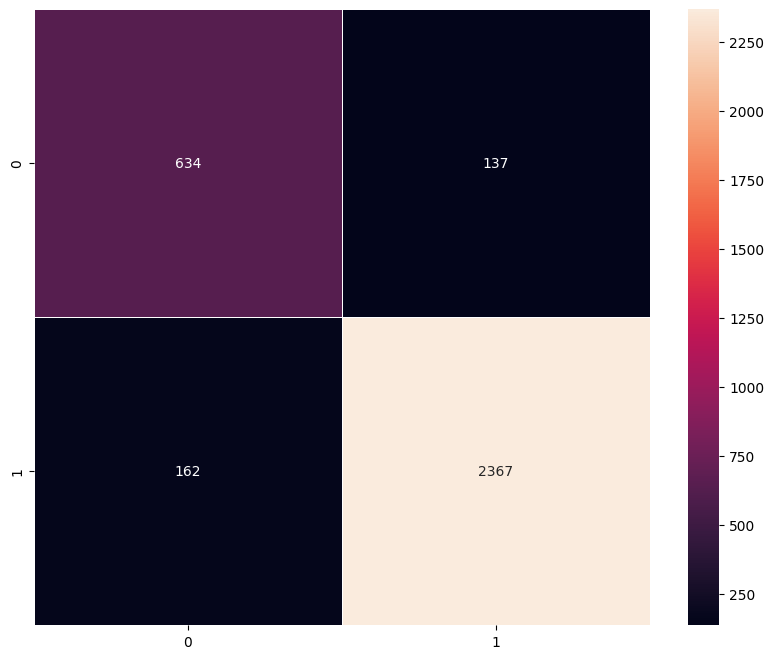

In [106]:
plot_confusion_matrix(model_5,X_train_normalized,y_train_encoded)

In [107]:
model_5_valid_perf = model_performance_classification(model_5, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_5_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.907767  0.867352   0.872809  0.870032


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step


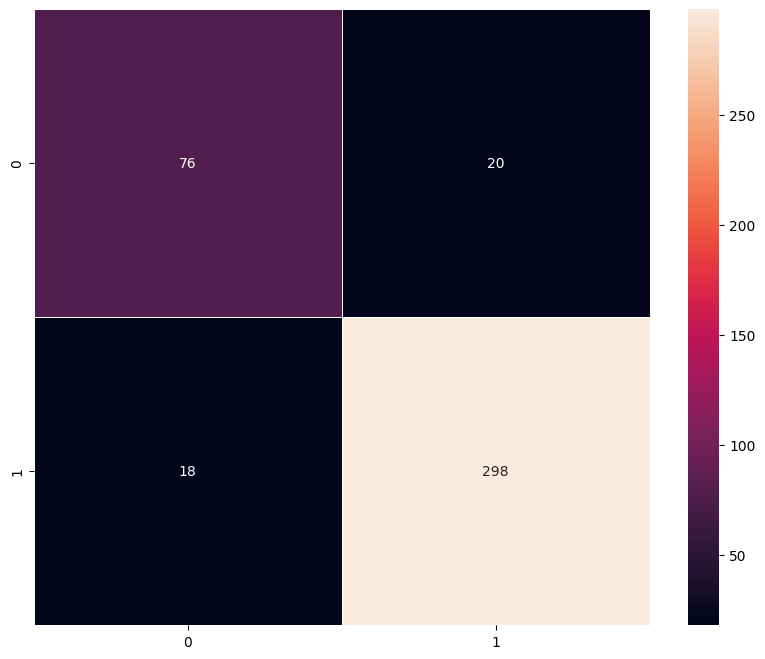

In [108]:
plot_confusion_matrix(model_5,X_val_normalized,y_val_encoded)

**Observations:**

* The model achieves approximately around 88% recall score on the training dataset.
* However, recall drops to around around 87% on the validation dataset.
* The model is well generalized.

#### Visualizing the predictions

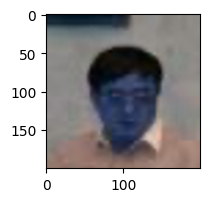

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
Predicted Label [0]
True Label 0


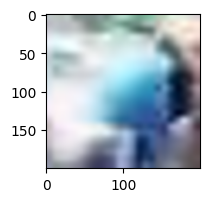

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Label [0]
True Label 1


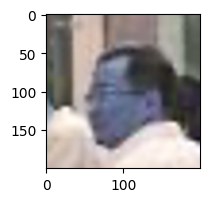

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Label [0]
True Label 0


In [109]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_5.predict((X_val_normalized[2].reshape(1,200,200,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
print('Predicted Label', enc.inverse_transform(model_5.predict((X_val_normalized[33].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()
print('Predicted Label', enc.inverse_transform(model_5.predict((X_val_normalized[36].reshape(1,200,200,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[36])

# **Model Performance Comparison and Final Model Selection**

In [111]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "CNN FROM SCRATCH","CNN FROM SCRATCH WITH DROPOUT","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [112]:
# validation performance comparison

models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T,
        model_5_valid_perf.T,
    ],
    axis=1,
)
models_valid_comp_df.columns = [
    "CNN FROM SCRATCH","CNN FROM SCRATCH WITH DROPOUT","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [113]:
models_train_comp_df

,CNN FROM SCRATCH,CNN FROM SCRATCH WITH DROPOUT,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.955758,0.951818,0.962424,0.968485,0.909394
Recall,0.916137,0.938812,0.949338,0.967267,0.879126
Precision,0.958949,0.928540,0.946135,0.947660,0.870885
F1 Score,0.935288,0.933529,0.947723,0.956953,0.874891


In [114]:
models_valid_comp_df

,CNN FROM SCRATCH,CNN FROM SCRATCH WITH DROPOUT,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.924757,0.900485,0.922330,0.917476,0.907767
Recall,0.856672,0.866232,0.887724,0.891812,0.867352
Precision,0.928091,0.858537,0.893483,0.880962,0.872809
F1 Score,0.885620,0.862280,0.890553,0.886195,0.870032


*  VGG-16 (Base+FFNN) has acheived the highest performance of ~ 97% but the validation set only went upto 89%. which shows the model is overfitted.

* VGG-16 (Base+FFNN+Data Agumentation) has acheived the good performance of about 88% in the training set. Also, it has acheived a good performance of ~ 87% recall in the validation set. With Accuracy of 90% on both Training and validation.

* We'll move ahead with the VGG-16 (Base+FFNN + Data Agumentaion) as our final model.

## Test Performance

In [115]:
model_5_test_perf = model_performance_classification(model_5, X_test_normalized,y_test_encoded)

13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


In [117]:
model_5_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.878935,0.831577,0.831577,0.831577


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step


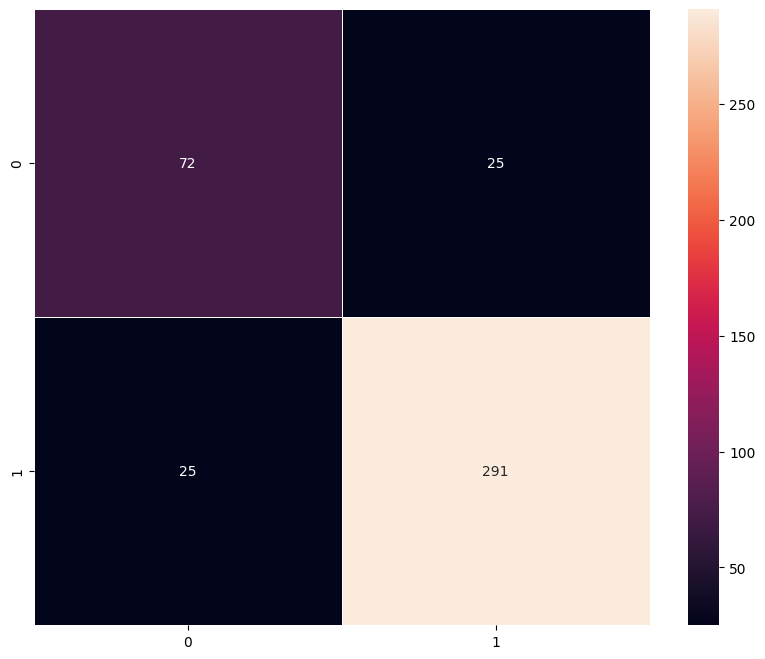

In [118]:
plot_confusion_matrix(model_5, X_test_normalized,y_test_encoded)

# **Actionable Insights & Recommendations**

* Adding a feed-forward neural network on top of the VGG-16 model significantly improved performance. This suggests that while the pre-trained features were beneficial, further refining them with an additional neural network tailored to our dataset enhanced the results.

* However, both the VGG-16-based models are experiencing overfitting. To address this, data augmentation techniques can be applied as a form of regularization.

* Although the performance of Model 5 is not on par with rest of the Models,but it does not suffer from overfitting.

* These final selected models can be further improved by training with adding extra FFNN layer.

* These models are trained on the original image_size of image i.e. 200 * 200 so all the models are able to give good performance.



<font size=5 color='blue'>Power Ahead!</font>
___